OpenCV Version: 4.13.0
Завантаження медіа та класифікаторів...
Файли успішно завантажені!

Знайдено осіб на фото 'petapixel6.jpg': 14
--- Відображення загальної сітки зображень ---


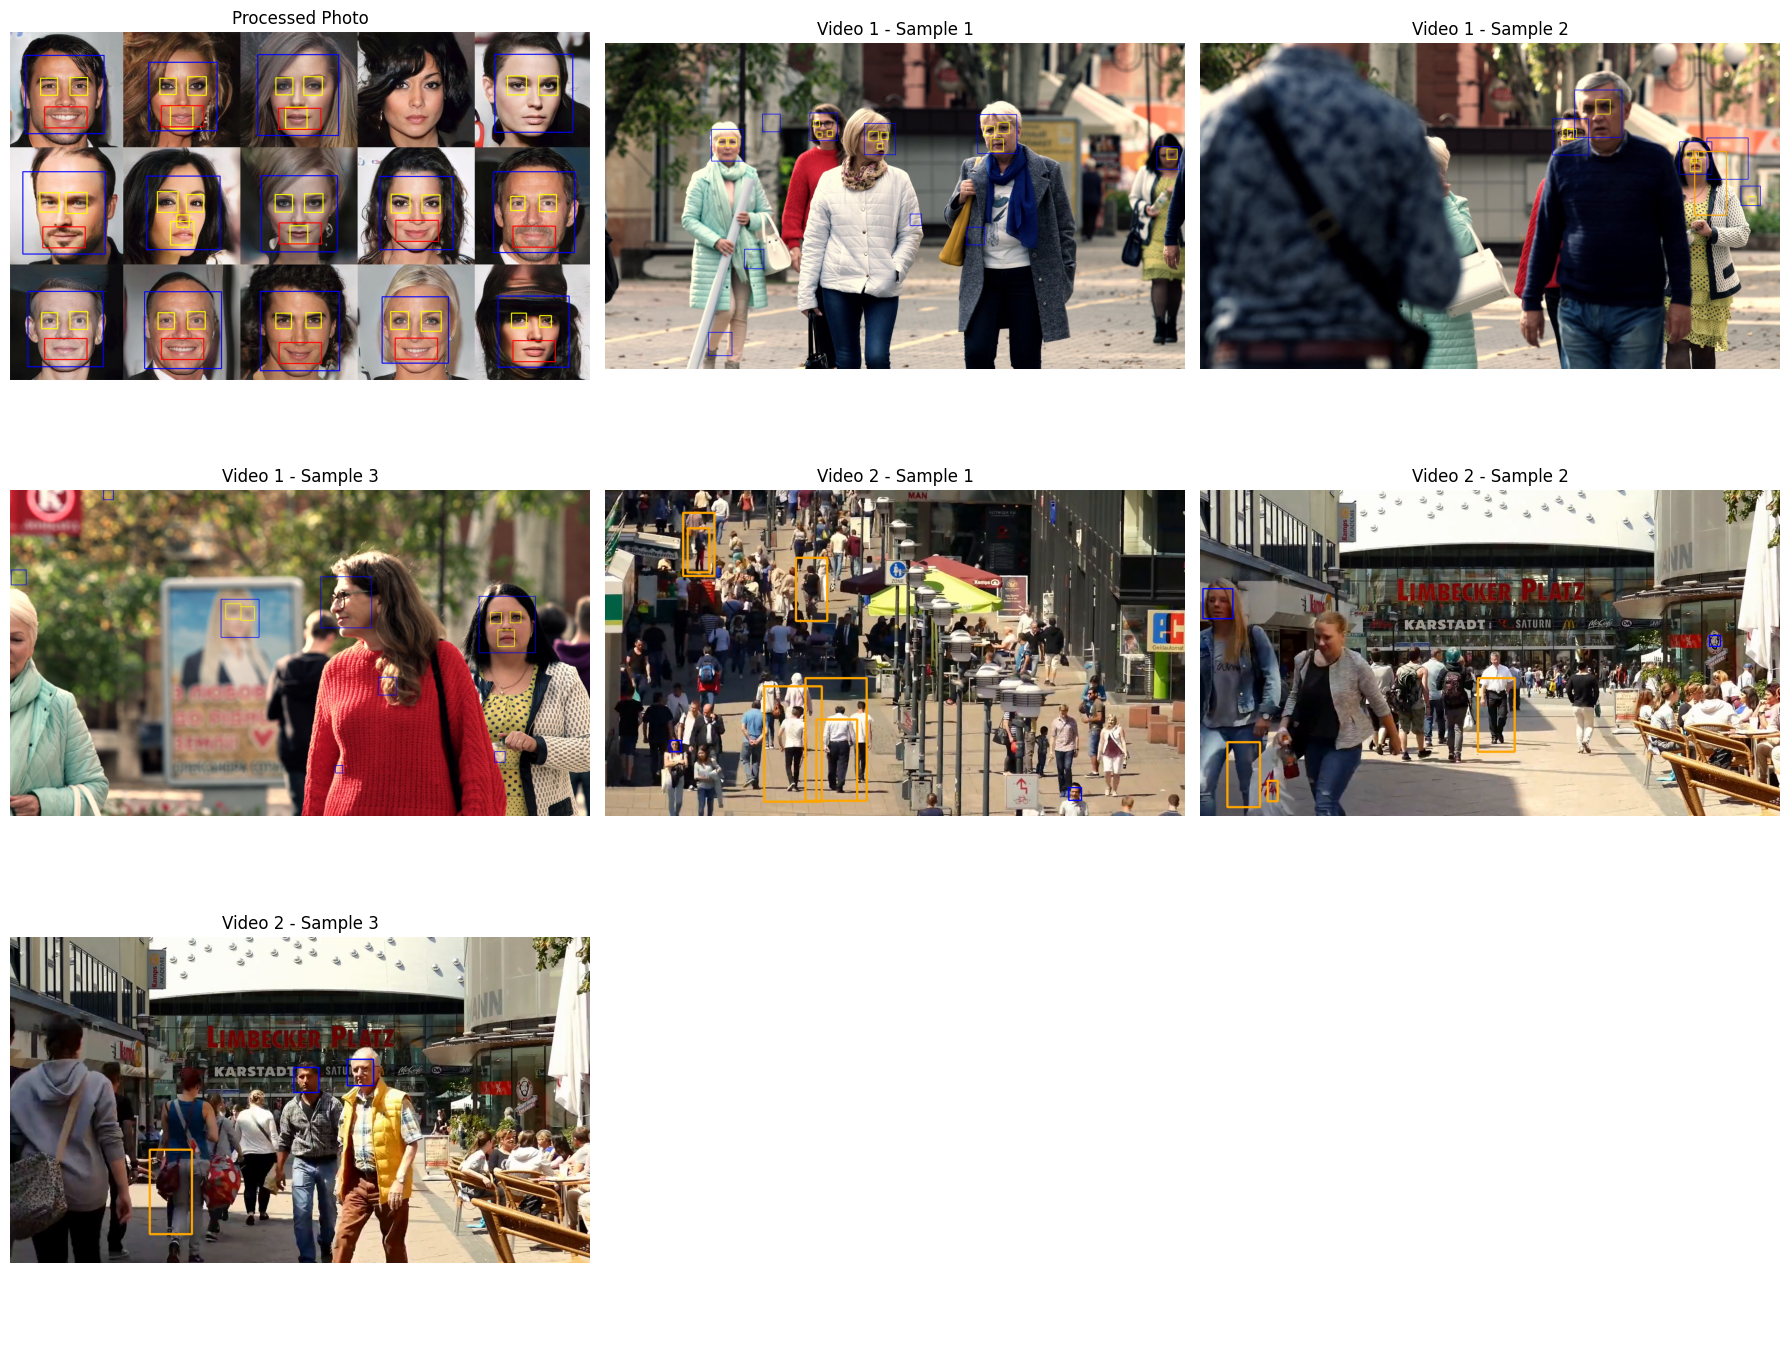


--- Відображення кожного зображення окремо ---



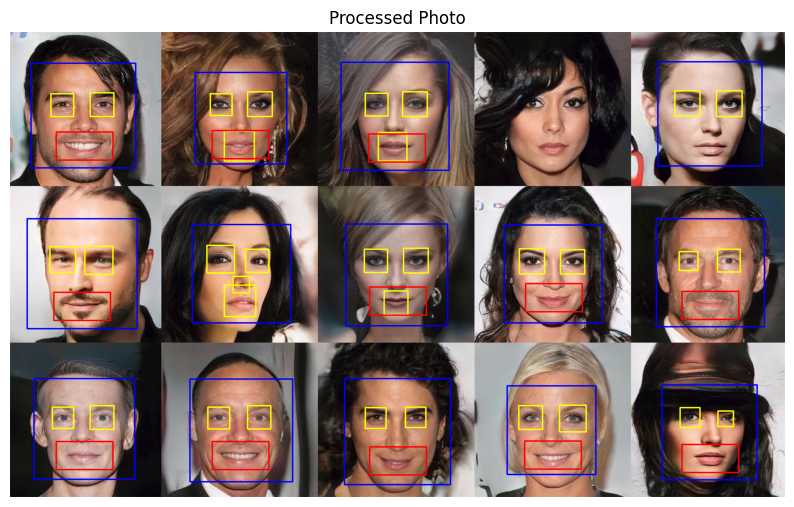

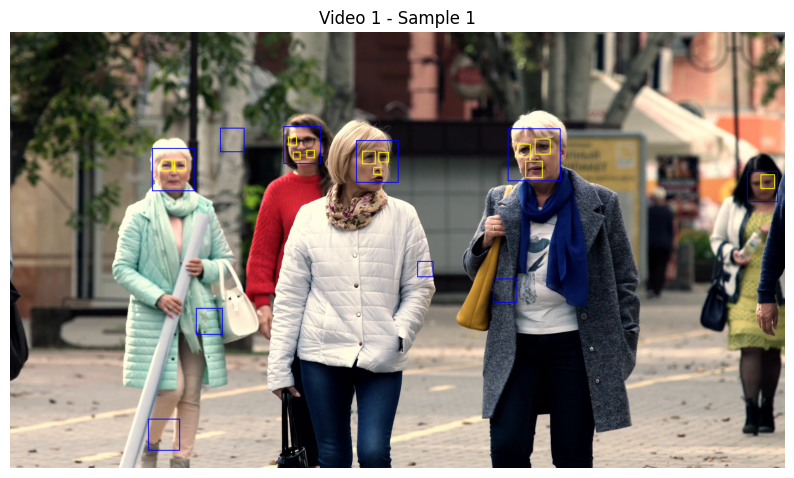

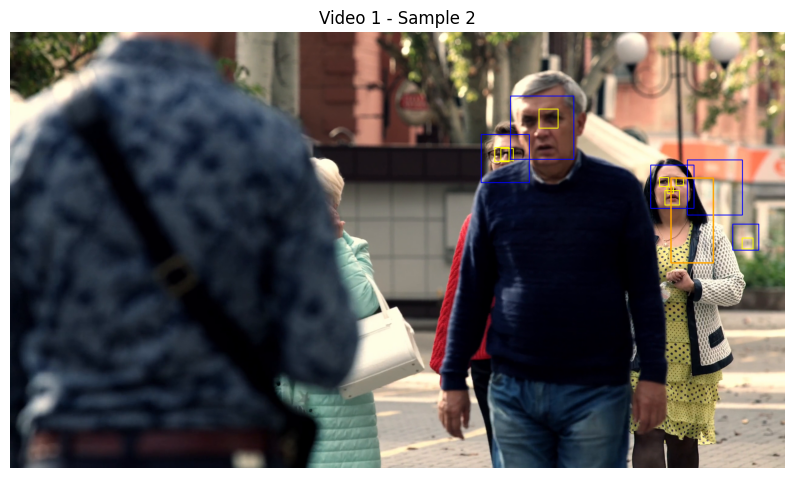

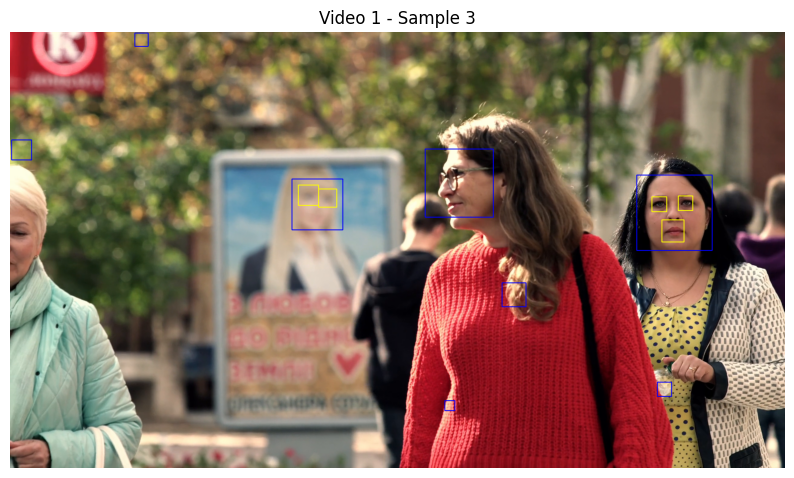

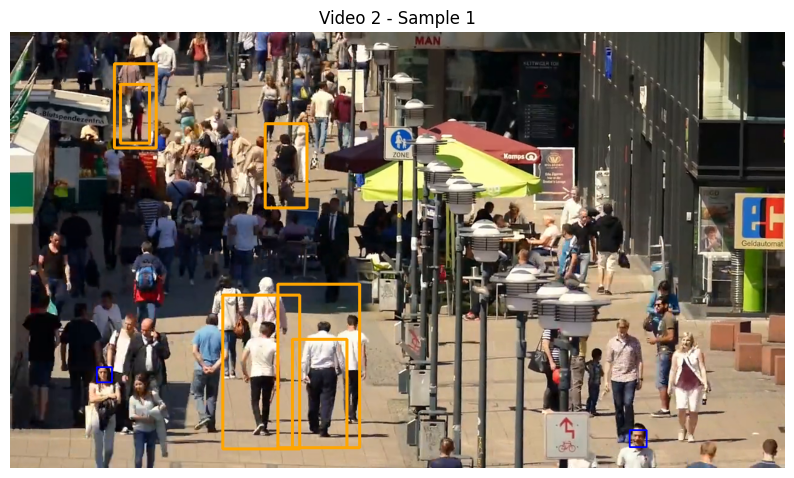

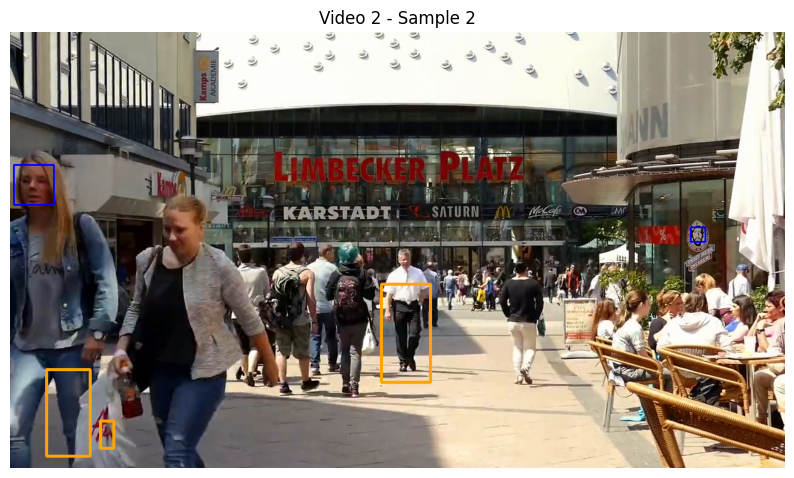

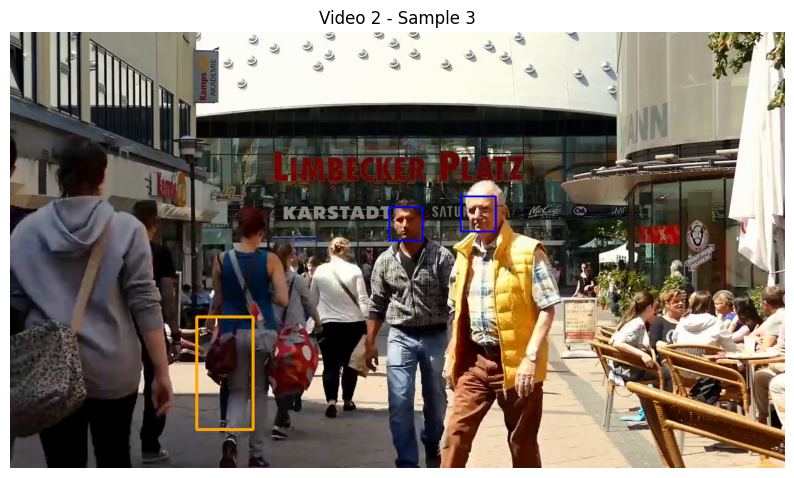


--- Відповіді на Контрольні запитання (Лабораторна робота №2) ---

1. Що таке алгоритм Віоли-Джонса?

Це метод детекції об'єктів (переважно облич) у реальному часі, запропонований Полом Віолою та Майклом Джонсом у 2001 році. Він базується на використанні ознак типу Хаара, інтегральних зображень для швидкого обчислення ознак та методу AdaBoost для відбору найважливіших ознак і створення каскаду класифікаторів.

2. Що таке haarcascade?

Це каскадний класифікатор на основі ознак Хаара. Це алгоритм машинного навчання, де каскадна функція тренується на великій кількості позитивних (зображення з об'єктом) та негативних (зображення без об'єкта) прикладів. Він дозволяє ефективно відсіювати області зображення, де об'єкта точно немає, значно прискорюючи процес пошуку.

3. Що таке HOG-класифікатор?

HOG (Histogram of Oriented Gradients — гістограма орієнтованих градієнтів) — це дескриптор ознак, що використовується в комп'ютерному зорі для виявлення об'єктів. Він аналізує розподіл інтенсивностей

In [2]:
import os
import cv2
import urllib.request
import matplotlib.pyplot as plt

# 1. --- Перевірка версії OpenCV ---
print("OpenCV Version:", cv2.__version__)

# --- Завантаження файлів з GitHub у робочу директорію Kaggle ---
base_url = "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/main/lab02/"

files_to_download = {
    "petapixel6.jpg": "petapixel6.jpg",
    "39837-424360872_medium.mp4": "39837-424360872_medium.mp4",
    "2121-155244120_medium.mp4": "2121-155244120_medium.mp4",
    "haarcascade_frontalface_default.xml": "haarcascade_frontalface_default.xml",
    "haarcascade_eye.xml": "haarcascade_eye.xml",
    "haarcascade_smile.xml": "haarcascade_smile.xml",
    "haarcascade_fullbody.xml": "haarcascade_fullbody.xml"
}

print("Завантаження медіа та класифікаторів...")
for filename, save_as in files_to_download.items():
    if not os.path.exists(save_as):
        urllib.request.urlretrieve(base_url + filename, save_as)
print("Файли успішно завантажені!\n")

# --- Ініціалізація каскадів ---
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')
body_cascade = cv2.CascadeClassifier('haarcascade_fullbody.xml')

def process_photo(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Помилка: Файл {image_path} не знайдено.")
        return None
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    print(f"Знайдено осіб на фото '{image_path}': {len(faces)}")
    
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 255), 2)
            
        smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def process_video_samples(video_path, num_samples=3):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Помилка: Неможливо відкрити відео {video_path}")
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = [int(total_frames * (i + 1) / (num_samples + 1)) for i in range(num_samples)]
    
    sample_frames = []
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: 
            continue
            
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)
        for (x, y, w, h) in faces:
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

            eyes = eye_cascade.detectMultiScale(roi_gray)
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 255), 2)
                
            smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)
            
        bodies = body_cascade.detectMultiScale(gray, 1.1, 3)
        for (x, y, w, h) in bodies:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 165, 255), 4)
            
        sample_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
    cap.release()
    return sample_frames

# --- Виконання обробки ---
photo_result = process_photo("petapixel6.jpg")
video1_samples = process_video_samples("39837-424360872_medium.mp4")
video2_samples = process_video_samples("2121-155244120_medium.mp4")

# --- Відображення усіх результатів у вигляді сітки (Big Image) ---
print("--- Відображення загальної сітки зображень ---")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

if photo_result is not None:
    axes[0].imshow(photo_result)
    axes[0].set_title("Processed Photo")
    axes[0].axis('off')

for i, frame in enumerate(video1_samples):
    axes[i+1].imshow(frame)
    axes[i+1].set_title(f"Video 1 - Sample {i+1}")
    axes[i+1].axis('off')

for i, frame in enumerate(video2_samples):
    axes[i+4].imshow(frame)
    axes[i+4].set_title(f"Video 2 - Sample {i+1}")
    axes[i+4].axis('off')

for i in range(7, 9):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# --- ВІДОБРАЖЕННЯ КОЖНОГО ЗОБРАЖЕННЯ ОКРЕМО ---
print("\n--- Відображення кожного зображення окремо ---\n")

if photo_result is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(photo_result)
    plt.title("Processed Photo")
    plt.axis('off')
    plt.show()

for i, frame in enumerate(video1_samples):
    plt.figure(figsize=(10, 10))
    plt.imshow(frame)
    plt.title(f"Video 1 - Sample {i+1}")
    plt.axis('off')
    plt.show()

for i, frame in enumerate(video2_samples):
    plt.figure(figsize=(10, 10))
    plt.imshow(frame)
    plt.title(f"Video 2 - Sample {i+1}")
    plt.axis('off')
    plt.show()

# --- Відповіді на Контрольні запитання (Лабораторна робота №2) ---
print("\n--- Відповіді на Контрольні запитання (Лабораторна робота №2) ---\n")

print("1. Що таке алгоритм Віоли-Джонса?\n")
print("Це метод детекції об'єктів (переважно облич) у реальному часі, запропонований Полом Віолою та Майклом Джонсом у 2001 році." \
" Він базується на використанні ознак типу Хаара, інтегральних зображень для швидкого обчислення ознак та методу AdaBoost для відбору найважливіших ознак" \
" і створення каскаду класифікаторів.\n")

print("2. Що таке haarcascade?\n")
print("Це каскадний класифікатор на основі ознак Хаара. Це алгоритм машинного навчання, де каскадна функція тренується на великій кількості позитивних" \
" (зображення з об'єктом) та негативних (зображення без об'єкта) прикладів. Він дозволяє ефективно відсіювати області зображення, де об'єкта точно немає," \
" значно прискорюючи процес пошуку.\n")

print("3. Що таке HOG-класифікатор?\n")
print("HOG (Histogram of Oriented Gradients — гістограма орієнтованих градієнтів) — це дескриптор ознак, що використовується в комп'ютерному зорі" \
" для виявлення об'єктів. Він аналізує розподіл інтенсивностей градієнтів (змін яскравості) у локальних областях зображення. Це дуже ефективно" \
" для виявлення об'єктів з чіткими формами (наприклад, людей, пішоходів).\n")

print("4. Що таке SVM-детектор?\n")
print("SVM (Support Vector Machine — метод опорних векторів) — це алгоритм машинного навчання, який використовується для класифікації даних." \
" У задачах комп'ютерного зору (наприклад, у поєднанні з HOG) він 'навчається' розрізняти вектор ознак об'єкта (наприклад, `людина` або `не людина`)," \
" знаходячи оптимальну роздільну гіперплощину між класами.\n")

print("5. Що робить метод cvtColor та яка його мета використання у цій лабораторній?\n")
print("Метод cv2.cvtColor() перетворює зображення з одного колірного простору в інший (наприклад, з BGR у Grayscale). У цій лабораторній роботі" \
" його мета — перетворити кольорове зображення на чорно-біле (градації сірого), оскільки для роботи алгоритмів пошуку облич чи пішоходів колірна" \
" інформація є надлишковою і лише ускладнює обчислення. Робота з одним каналом (сірим) значно швидша і точніша для класифікаторів Хаара.\n")
